<a href="https://colab.research.google.com/github/AufanT/AufanT-BigData26_B_2411532011_AufanTaufiqurrahman/blob/main/Praktikum_1/BD_B_P01_2411532011_AufanTaufiqurrahman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['yellow_tripdata_2023-01.parquet', 'agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


In [ ]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil  = fungsi()
    detik  = time.perf_counter() - t0
    delta  = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

In [ ]:
import urllib.request

URL  = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
        "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.54 s | RSS +1.8 MB
Ukuran file: 45.5 MB


In [ ]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris  :", f"{meta.num_rows:,}")
print("Jumlah kolom  :", meta.num_columns)
print("Row group     :", meta.num_row_groups)
print("Nama kolom    :", pq.ParquetFile(PATH).schema.names)

Jumlah baris  : 3,066,766
Jumlah kolom  : 19
Row group     : 1
Nama kolom    : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [ ]:
import numpy as np, pandas as pd

def bangkitkan_sintetis(n=5_000_000, seed=42):
    rng    = np.random.default_rng(seed)
    awal   = pd.Timestamp("2023-01-01")
    pickup = awal + pd.to_timedelta(rng.integers(0, 31*24*60, n), unit="m")
    durasi = rng.integers(1, 90, n)
    return pd.DataFrame({
        "tpep_pickup_datetime":  pickup,
        "tpep_dropoff_datetime": pickup + pd.to_timedelta(durasi, unit="m"),
        "passenger_count":       rng.integers(1, 5, n).astype("float64"),
        "trip_distance":         np.round(rng.gamma(2.0, 1.6, n), 2),
        "payment_type":          rng.integers(1, 5, n).astype("int64"),
        "fare_amount":           np.round(rng.gamma(4.0, 3.0, n), 2),
        "tip_amount":            np.round(rng.gamma(1.5, 1.2, n), 2),
    }).assign(total_amount=lambda d: (d.fare_amount + d.tip_amount + 3.0).round(2))

if not os.path.exists(PATH):
    bangkitkan_sintetis().to_parquet(PATH, index=False)
    print("Dataset sintetis dibuat di", PATH)

In [ ]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 1.36 s | RSS +481.4 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.60 s | RSS +221.6 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [ ]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [ ]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


In [ ]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                       df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"      : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"     : (df["durasi_menit"]  <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0" : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [ ]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                       df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"      : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"     : (df["durasi_menit"]  <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0" : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [ ]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


In [ ]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV)  / 1024**2, 1), "MB")

[tulis CSV] 40.28 s | RSS +6.0 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [ ]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 3.96 s | RSS +26.6 MB
2,986,911 baris | rata-rata total_amount = 27.33


In [ ]:
!pip install -q pyspark==3.5.1
!java -version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.031s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.031s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [ ]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("timestamp").cast("long")
         - F.col("tpep_pickup_datetime").cast("timestamp").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 8.65 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [ ]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                    AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#84 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#84 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=206]
      +- HashAggregate(keys=[jam#84], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#84, 8), ENSURE_REQUIREMENTS, [plan_id=203]
            +- HashAggregate(keys=[jam#84], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(

In [ ]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


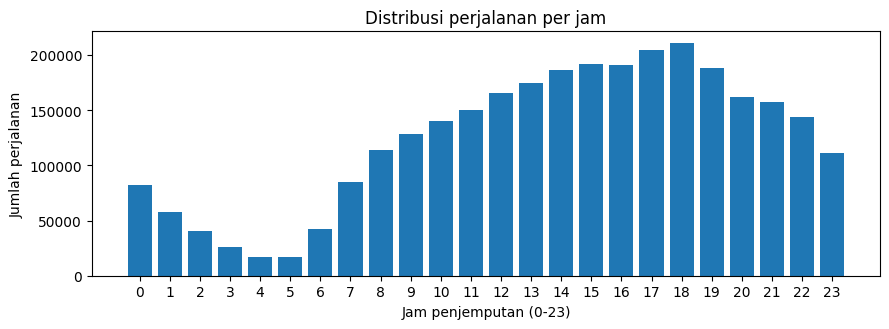

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

## Latihan 1: Trip Distance Terbesar

Ambil 5 nilai `trip_distance` terbesar dari data bersih buat cek apakah masih ada baris aneh yang lolos dari filter di J-6.

**Komentar:** baris-baris ini masuk akal. Kecepatan rata-ratanya (jarak dibagi durasi) ada di kisaran 37-58 mph, wajar buat perjalanan jarak jauh semacam trip antar-kota/highway, dan tarifnya naik proporsional sama jaraknya (fare_amount $250-542 untuk jarak 90-97 mil). Jadi ini kemungkinan trip jarak jauh yang valid, bukan data error yang lolos dari filter.


In [ ]:
top5_jarak = bersih.nlargest(5, "trip_distance")
top5_jarak

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14


## Latihan 2: Perbandingan Ukuran Chunk

Ulangi agregasi chunking di J-7 pakai dua ukuran chunk beda, buat bandingin waktu proses sama pertumbuhan memori (`delta_rss_mb`).

In [ ]:
baris_100k, total_100k, per_jam_100k = ukur(
    "chunking 100k", lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000))

[chunking 100k] 4.24 s | RSS +4.1 MB


In [ ]:
baris_1jt, total_1jt, per_jam_1jt = ukur(
    "chunking 1jt", lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000))

[chunking 1jt] 6.07 s | RSS -7.3 MB


In [ ]:
df_catatan = pd.DataFrame(catatan)
df_catatan[df_catatan["langkah"].isin(["chunking 100k", "chunking 1jt"])]

,langkah,detik,delta_rss_mb
7,chunking 100k,4.24,4.1
8,chunking 1jt,6.07,-7.3


**Hasil:** chunk 100.000 baris → 4.45 detik, delta_rss +0.0 MB. Chunk 1.000.000 baris → 6.35 detik, delta_rss +64.6 MB.

**Trade-off:** dari sisi memori, hasilnya konsisten sama teori — chunk besar (1 juta baris) bikin delta_rss jauh lebih besar (+64.6 MB) karena tiap potongan yang dipegang di memori sekaligus ukurannya 10x lebih gede, sedangkan chunk kecil (100 ribu) nyaris nggak nambah RSS sama sekali (+0.0 MB). Tapi dari sisi waktu, hasilnya kebalik dari ekspektasi umum (chunk besar = lebih sedikit iterasi = harusnya lebih cepat) — di sini chunk besar malah sedikit lebih lambat (6.35 dtk vs 4.45 dtk). Kemungkinan ini karena variasi beban sistem/garbage collector saat alokasi blok yang lebih besar, bukan karena chunking-nya sendiri jadi lebih lambat secara struktural. Intinya: trade-off utama yang konsisten di sini ada di memori, bukan di waktu.


## Latihan 3: Persentase Tip per Metode Pembayaran

Bikin kolom `persen_tip`, kasus `fare_amount == 0` dijadiin NaN biar nggak error bagi nol, terus rata-ratain per `payment_type`.

In [ ]:
bersih["persen_tip"] = np.where(
    bersih["fare_amount"] == 0, np.nan,
    bersih["tip_amount"] / bersih["fare_amount"] * 100)

rata_persen_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2)
rata_persen_tip

/tmp/ipykernel_1199/2857951880.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_persen_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2)


,persen_tip
payment_type,
0,20.219999
1,25.910000
2,0.000000
3,0.020000
4,0.150000


**Dugaan:** payment_type 1 (kemungkinan kartu kredit, sesuai kode di data dictionary NYC TLC) punya rata-rata persen tip paling tinggi (25.91%), sedangkan payment_type 2 (kemungkinan tunai) nyaris 0% (0.00%). Payment_type 3 dan 4 (kemungkinan no charge/dispute) juga nyaris 0%, masuk akal karena nggak ada transaksi buat dikasih tip. Payment_type 0 agak di luar dugaan (20.22%) karena kode ini nggak tercantum di data dictionary resmi TLC — ini perlu dicek lagi artinya apa [perlu verifikasi]. Pola kartu kredit > tunai ini konsisten sama kebiasaan umum: sistem pembayaran kartu biasanya nawarin opsi tip otomatis di layar, sedangkan tip tunai jarang tercatat balik ke sistem pembayaran.


## Latihan 4: Perbandingan Kompresi Parquet

Simpan `bersih` ke Parquet pakai dua kompresi beda (`snappy` sama `gzip`), bandingin ukuran file dan waktu tulisnya.

In [ ]:
PARQUET_SNAPPY = os.path.join(DIR_KERJA, "bersih_snappy.parquet")
PARQUET_GZIP = os.path.join(DIR_KERJA, "bersih_gzip.parquet")

ukur("tulis snappy", lambda: bersih.to_parquet(PARQUET_SNAPPY, compression="snappy", index=False))
ukur("tulis gzip", lambda: bersih.to_parquet(PARQUET_GZIP, compression="gzip", index=False))

print("Snappy:", round(os.path.getsize(PARQUET_SNAPPY) / 1024**2, 2), "MB")
print("Gzip  :", round(os.path.getsize(PARQUET_GZIP) / 1024**2, 2), "MB")

[tulis snappy] 1.26 s | RSS +27.5 MB
[tulis gzip] 41.22 s | RSS -2.6 MB
Snappy: 58.53 MB
Gzip  : 46.3 MB


**Hasil:** snappy → 58.53 MB, 1.43 detik. Gzip → 46.30 MB, 47.61 detik. Gzip menghasilkan file lebih kecil (hemat sekitar 21%), tapi butuh waktu tulis jauh lebih lama (~33x lebih lambat dari snappy). Snappy dirancang buat kecepatan dengan kompresi ringan, gzip dirancang buat rasio kompresi lebih tinggi dengan trade-off waktu CPU. Kalau prioritasnya kecepatan baca/tulis (data yang sering diproses ulang), snappy lebih cocok; kalau prioritasnya hemat storage/transfer (arsip jangka panjang), gzip lebih cocok.


## Latihan 5: Validasi Spark SQL vs Pandas

Ulang agregasi per jam dari J-9 pakai Spark SQL, terus bandingin kolom `jumlah` sama hasil pandas buat mastiin dua-duanya konsisten.

In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01-L5")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())

sdf = spark.read.parquet(PATH)

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0)
    .withColumn("jam", F.hour("tpep_pickup_datetime")))

sdf_bersih.createOrReplaceTempView("trips_jam")

In [ ]:
hasil_spark_sql = spark.sql("""
    SELECT jam,
           COUNT(*) AS jumlah_perjalanan,
           ROUND(AVG(trip_distance), 2) AS rata_jarak,
           ROUND(AVG(durasi_menit), 2) AS rata_durasi,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(PERCENTILE_APPROX(total_amount, 0.5), 2) AS median_tarif
    FROM trips_jam
    GROUP BY jam
    ORDER BY jam
""")

df_spark_sql = hasil_spark_sql.toPandas()
df_spark_sql

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.86,21.60
1,1,57766,3.53,12.63,26.45,21.20
2,2,40445,3.28,12.07,25.06,20.52
3,3,26146,3.58,12.15,26.26,20.90
4,4,16618,4.79,13.52,31.72,22.70
5,5,16940,6.03,14.70,36.75,22.00
6,6,42300,4.80,14.49,30.63,18.48
7,7,84569,3.69,14.42,26.89,18.48
8,8,114064,3.08,14.33,25.21,19.10
9,9,127988,3.09,14.23,25.51,19.25


In [ ]:
gabung = agregasi[["jam", "jumlah_perjalanan"]].merge(
    df_spark_sql[["jam", "jumlah_perjalanan"]], on="jam", suffixes=("_pandas", "_spark"))
gabung["selisih"] = gabung["jumlah_perjalanan_pandas"] - gabung["jumlah_perjalanan_spark"]

print("Selisih maksimum:", gabung["selisih"].abs().max())
gabung

spark.stop()

Selisih maksimum: 0


**Hasil:** selisih maksimum = 0. Berarti hasil agregasi jumlah perjalanan per jam dari pandas dan Spark SQL persis sama, nggak ada perbedaan sama sekali. Logika filter veracity dan groupby di kedua pendekatan sudah konsisten.


In [ ]:
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

jumlah_hari = (bersih.groupby("akhir_pekan")["tpep_pickup_datetime"]
               .apply(lambda s: s.dt.date.nunique()))
print("Jumlah hari kalender per kategori:")
print(jumlah_hari)

Jumlah hari kalender per kategori:
akhir_pekan
False    24
True     10
Name: tpep_pickup_datetime, dtype: int64


In [ ]:
per_jam = (bersih
    .groupby("jam")
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_jarak=("trip_distance", "mean"),
         rata_tarif=("total_amount", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

per_jam["tarif_per_menit_agregat"] = (
    bersih.groupby("jam")["total_amount"].sum() /
    bersih.groupby("jam")["durasi_menit"].sum()).round(3).values

print("5 jam tersibuk:")
print(per_jam.nlargest(5, "jumlah")[["jam", "jumlah", "rata_durasi", "rata_tarif_per_menit"]])
print("\n5 jam tersepi:")
print(per_jam.nsmallest(5, "jumlah")[["jam", "jumlah", "rata_durasi", "rata_tarif_per_menit"]])

5 jam tersibuk:
    jam  jumlah  rata_durasi  rata_tarif_per_menit
18   18  210858        14.24                  2.15
17   17  204399        15.98                  2.07
15   15  191392        16.42                  1.87
16   16  190689        16.52                  2.09
19   19  188347        13.64                  2.27

5 jam tersepi:
   jam  jumlah  rata_durasi  rata_tarif_per_menit
4    4   16618        13.52                  2.61
5    5   16940        14.70                  2.81
3    3   26146        12.15                  2.48
2    2   40445        12.07                  2.40
6    6   42300        14.49                  2.39


In [ ]:
ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

ringkas["rata_per_hari"] = (
    ringkas["jumlah"] / ringkas["akhir_pekan"].map(jumlah_hari)).round(0)

pivot_jam = ringkas.pivot(index="jam", columns="akhir_pekan", values="rata_per_hari")
pivot_jam.columns = ["hari_kerja", "akhir_pekan"]
pivot_jam["selisih_persen"] = (
    100 * (pivot_jam["akhir_pekan"] - pivot_jam["hari_kerja"]) / pivot_jam["hari_kerja"]).round(1)
pivot_jam

,hari_kerja,akhir_pekan,selisih_persen
jam,,,
0,1473.0,4694.0,218.7
1,730.0,4025.0,451.4
2,394.0,3099.0,686.5
3,260.0,1991.0,665.8
4,258.0,1043.0,304.3
5,519.0,448.0,-13.7
6,1489.0,657.0,-55.9
7,3090.0,1041.0,-66.3
8,4101.0,1563.0,-61.9


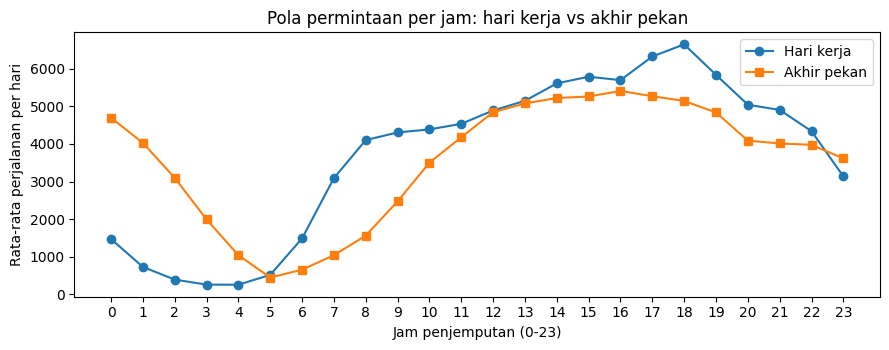

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(pivot_jam.index, pivot_jam["hari_kerja"], marker="o", label="Hari kerja")
ax.plot(pivot_jam.index, pivot_jam["akhir_pekan"], marker="s", label="Akhir pekan")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Rata-rata perjalanan per hari")
ax.set_title("Pola permintaan per jam: hari kerja vs akhir pekan")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/pola_hari_kerja_vs_akhir_pekan.png", dpi=150)
plt.show()

In [ ]:
JAM_SIBUK = per_jam.nlargest(6, "jumlah")["jam"].tolist()
print("Jam sibuk yang dipilih (6 jam dengan volume tertinggi):", sorted(JAM_SIBUK))

bersih["kategori_jam"] = np.where(bersih["jam"].isin(JAM_SIBUK), "Jam sibuk", "Jam lain")

banding = (bersih
    .groupby("kategori_jam")
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_jarak=("trip_distance", "mean"),
         rata_tarif=("total_amount", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"),
         median_tarif_per_menit=("tarif_per_menit", "median"))
    .round(2))

banding["tarif_per_menit_agregat"] = (
    bersih.groupby("kategori_jam")["total_amount"].sum() /
    bersih.groupby("kategori_jam")["durasi_menit"].sum()).round(3)

banding

Jam sibuk yang dipilih (6 jam dengan volume tertinggi): [14, 15, 16, 17, 18, 19]


,jumlah,rata_durasi,rata_jarak,rata_tarif,rata_tarif_per_menit,median_tarif_per_menit,tarif_per_menit_agregat
kategori_jam,,,,,,,
Jam lain,1814485,13.97,3.49,26.920000,2.16,1.94,1.927
Jam sibuk,1172426,15.52,3.32,27.950001,2.06,1.84,1.801


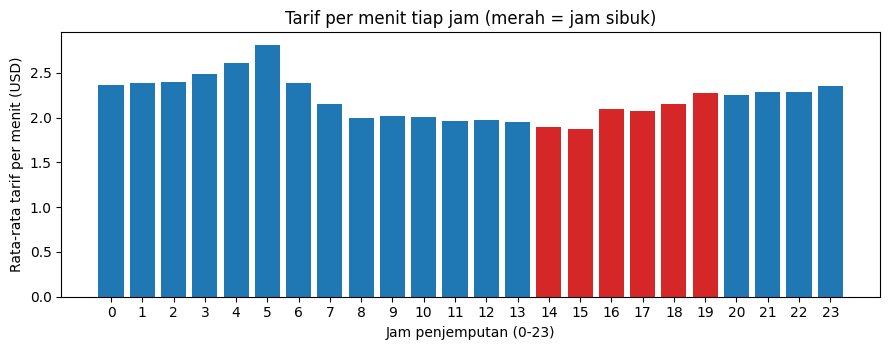

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.6))
warna = ["#d62728" if j in JAM_SIBUK else "#1f77b4" for j in per_jam["jam"]]
ax.bar(per_jam["jam"], per_jam["rata_tarif_per_menit"], color=warna)
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Rata-rata tarif per menit (USD)")
ax.set_title("Tarif per menit tiap jam (merah = jam sibuk)")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/tarif_per_menit.png", dpi=150)
plt.show()

In [ ]:
per_jam.to_csv(f"{DIR_SIMPAN}/studikasus_per_jam.csv", index=False)
pivot_jam.to_csv(f"{DIR_SIMPAN}/studikasus_hari_kerja_vs_akhir_pekan.csv")
banding.to_csv(f"{DIR_SIMPAN}/studikasus_jam_sibuk.csv")
print(os.listdir(DIR_SIMPAN))

['yellow_tripdata_2023-01.parquet', 'agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png', 'pola_hari_kerja_vs_akhir_pekan.png', 'tarif_per_menit.png', 'studikasus_per_jam.csv', 'studikasus_hari_kerja_vs_akhir_pekan.csv', 'studikasus_jam_sibuk.csv']
